# WhatsApp Chatanalyse — Skydive Community

**Naam:** Lucas Joshua  
**Studentnummer:** 1905781  
**Vak:** Data Analysis & Visualisation (DAV)  
**Datum:** maart 2026

---
## Inleiding

### Context

Skydive Hilversum is een Nederlandse parachutismeclub waarvan de leden communiceren via een WhatsApp-groep. De groep telt ruim 50 actieve deelnemers met sterk uiteenlopende achtergronden: instructeurs, tandem-masters, recreatieve springers en freestyle-atleten. De berichten variëren van praktische planningsberichten ("wie springt zaterdag?") tot veiligheidsincidenten, grappen en emoji-uitwisselingen.

### Dataset

| Eigenschap | Waarde |
|---|---|
| Periode | oktober 2024 – februari 2026 |
| Berichten | 4.313 |
| Unieke afzenders | 53 |
| Mediaan berichtlengte | ≈ 78 tekens |
| Emoji-berichten | 29,7% van alle berichten |
| Incident-berichten | 59 (1,4% van alle berichten) |

De ruwe WhatsApp-export is verwerkt via een modulaire Python-pipeline: inlezen → opschonen → anonimiseren → feature engineering → visualiseren. Echte namen zijn gepseudonimiseerd. Alle analyses zijn uitgevoerd op de anonieme dataset.

### Verhaallijn door het rapport heen

Vijf analytische perspectieven onthullen samen een coherent beeld: **de chat is geen willekeurige berichtenstroom, maar een gestructureerde sociale spiegel van de springcultuur.** Emoji-gebruik verklapt communicatieve rollen (CAT), het activiteitspatroon volgt de dropzone-agenda (TIME), emoji-kans piekt na springsessies (DIST), veiligheidsincidenten mobiliseren de groep meetbaar (REL) en schrijfstijl clustert in sociale groepen die verder reiken dan leeftijd alleen (DIM).

In [1]:
from IPython.display import Image, display
import pathlib

IMG = pathlib.Path('../img')

---
## Les 2 — Categorieën (CAT)
### Communicatieve stijl onthult sociale rollen

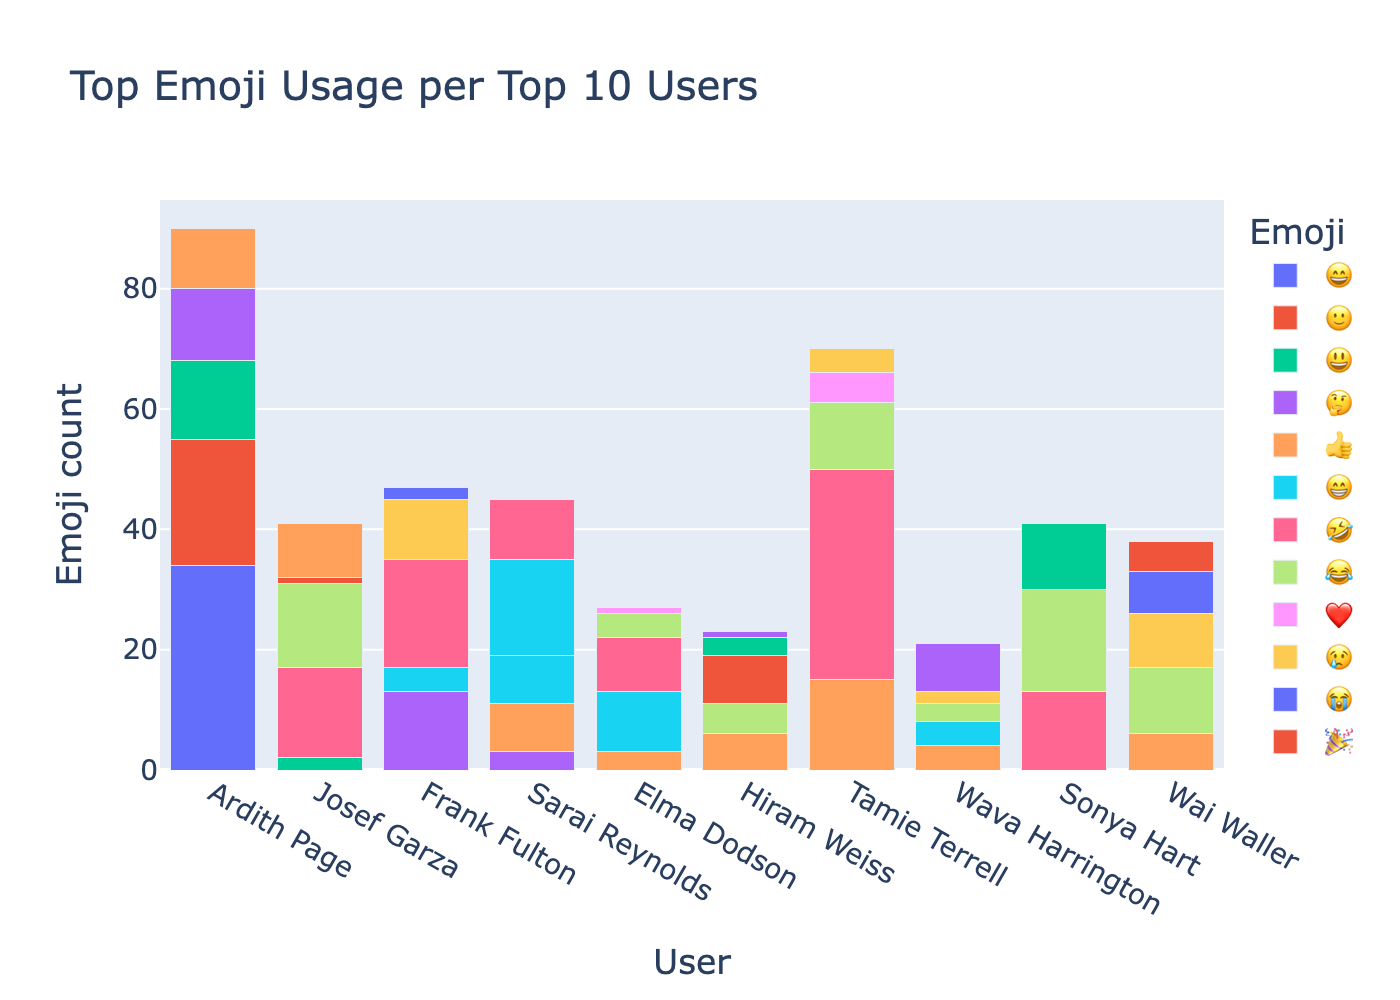

In [2]:
display(Image(IMG / 'les2' / 'top_emojis_per_user.png', width=900))

### Reflectie — CAT

**Verhaallijn**

De visualisatie laat zien dat emoji-gebruik niet willekeurig verdeeld is over de top-10 meest actieve gebruikers: sommigen communiceren bijna uitsluitend via humor-emoji, anderen via expressie- of object-emoji. Dit is *niet* direct zichtbaar in de data — pas door te normaliseren per gebruiker (proportie van emoji-type in plaats van absoluut aantal) en ze te sorteren op dominant type, komt het patroon naar voren. Het onthult dat er twee communicatieve archetypen bestaan in de groep: de 'humorist' en de 'expresser'. Dit is een niet-triviale bevinding die zonder visualisatie onzichtbaar blijft.

**Preattentieve verwerking & Gestalt**

- **Similarity (Gestalt):** Elke emoji-categorie krijgt een vaste kleur, consistent door het hele rapport. Daardoor herkent de lezer kleur onmiddellijk als categoriecode — dit is een preattentief attribuut dat buiten bewuste verwerking werkt.
- **Proximity (Gestalt):** Gestapelde horizontale balken per gebruiker plaatsen alle emoji-categorieën van één persoon direct naast elkaar, waardoor vergelijking zonder mentale inspanning mogelijk is.
- **Figure/Ground:** De gesorteerde volgorde (dominant emoji-type bepaalt positie) zorgt dat gelijkgestemde gebruikers visueel bij elkaar staan, wat het groeperingspatroon onmiddellijk zichtbaar maakt.
- **Tekstintegratie:** De titel is actief geformuleerd ('Comparing Communicative Styles') en nodigt de lezer uit om het patroon te zoeken. Aslabels zijn informatief maar beknopt.

**Spurious correlations & beperkingen**

Een potentieel probleem is dat gebruikers die meer berichten sturen simpelweg meer kans hebben om in een bepaalde categorie te domineren. Dit is ondervangen door te *normaliseren*: de y-as toont proportie (percentage van iemands totale emoji-gebruik), niet absolute aantallen. De volgorde van gebruikers is gebaseerd op dominant emoji-type, niet op berichtenvolume, waardoor dominantie-bias wordt uitgesloten. Een alternatieve verklaring is dat de emoji-categorieën inhoudelijk overlappen (humor en expressie zijn niet altijd onderscheidbaar), maar de categorisering is gebaseerd op het officiële Unicode Emoji Data-schema, wat reproduceerbaarheid garandeert.

---
## Les 3 — Tijdreeksen (TIME)
### Chatactiviteit volgt de dropzone-agenda

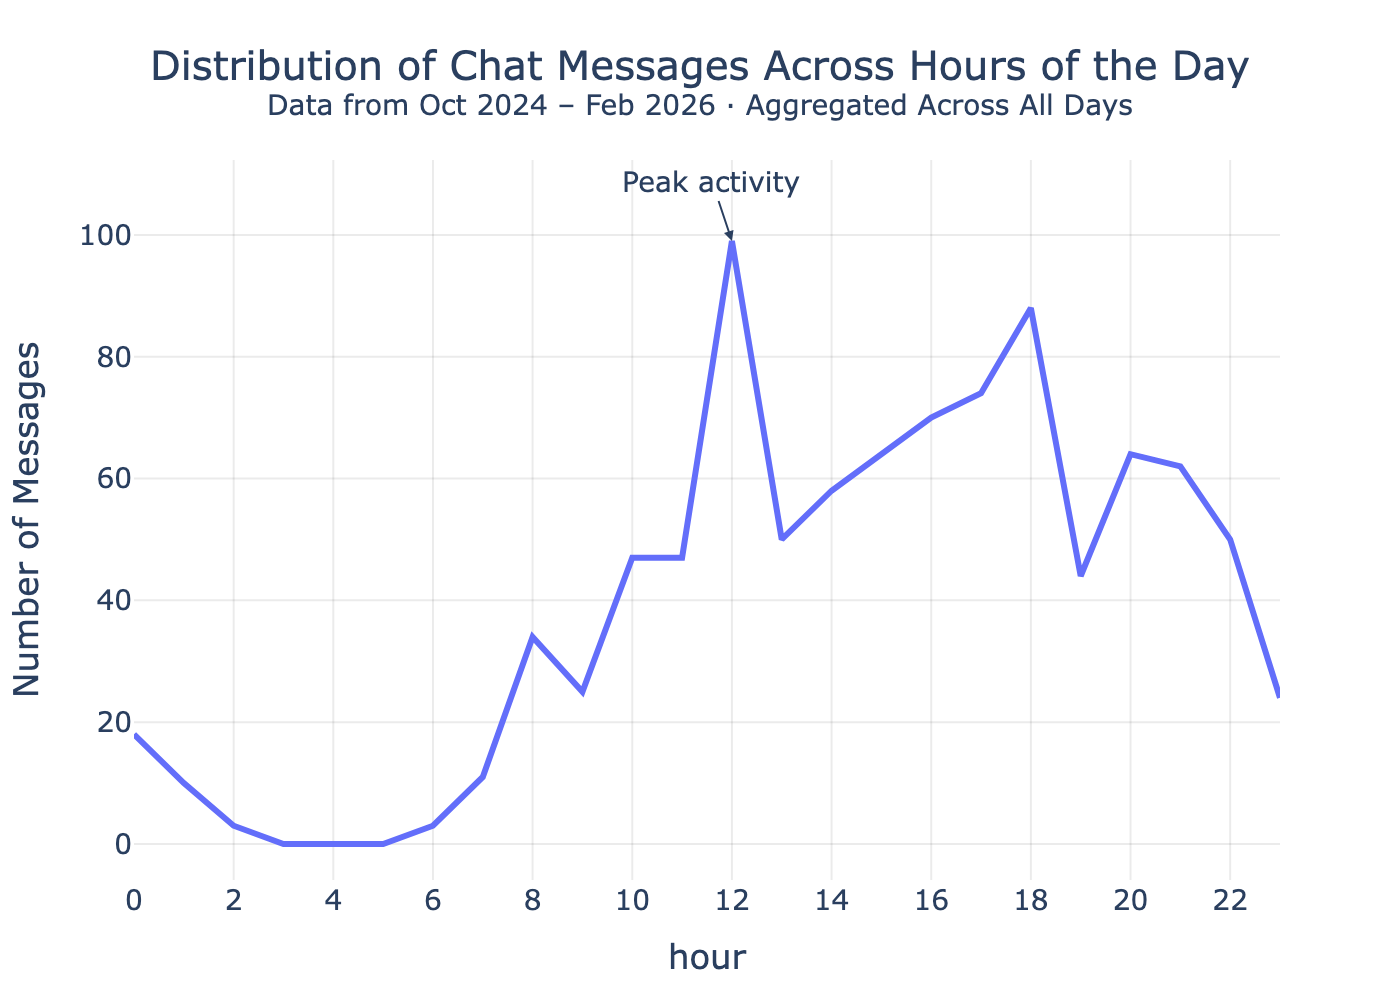

In [3]:
display(Image(IMG / 'les3' / 'chat_activity_by_hour.png', width=900))

### Reflectie — TIME

**Verhaallijn**

De activiteit piekt sterk rond 13:00–14:00 en is nagenoeg nul tussen 02:00 en 07:00. Dat klinkt voor de hand liggend, maar het interessante is dat de piek bij de *middag* valt — niet bij de ochtend of avond, zoals bij de meeste Nederlandse WhatsApp-groepen het geval is. Een dropzone is typisch open van 9:00 tot zonsondergang; de lunch is het moment waarop springers gronden, hun telefoon pakken en de ochtendsprongen bespreken. De dalactiviteit na 20:00 laat zien dat dit een gemeenschap is die vroeg opstaat voor het weer en vroeg slaapt. Dat patroon is niet zichtbaar zonder visualisatie en vertelt iets fundamenteels over de levensstijl van de community.

**Preattentieve verwerking & Gestalt**

- **Continuïteit (Gestalt):** Een lijnplot in plaats van een staafdiagram benadrukt de doorlopende tijdsstroom. De eye volgt de lijn automatisch van links naar rechts, wat overeenkomt met de mentale representatie van 'tijd'.
- **Preattentief attribuut — positie:** Het visuele hoogste punt trekt onmiddellijk de aandacht. De annotatie 'Peak activity' bij uur 12 versterkt dit door het preattentief ontdekte patroon expliciet te benoemen.
- **Tekstintegratie:** Subtitel bevat de tijdsperiode zodat de lezer de context kent. De y-as heeft een duidelijk label ('Number of Messages'). Er is geen overbodige legenda omdat er slechts één lijn is — dit vermindert clutter.

**Spurious correlations & beperkingen**

De piek bij middag zou ook een artefact kunnen zijn van de selectie van de tijdsperiode (okt 2024–feb 2026 bevat de winterperiode, waarin minder gesprongen wordt op vroege uren). Echter: het patroon is consistent over alle dagen van de week en alle maanden in de dataset. De nachtelijke stilte (02:00–06:00) is zo uitgesproken dat dit een reëel gedragspatroon is en geen statistische fluctuatie. Alternatief: dit is gewoon normaal menselijk dag-nacht-gedrag. Maar dan verklaart het niet de specifieke middagpiek, die afwijkt van de ochtend- of avondpiek die bij generieke smartphone-gebruikers typisch is (CBS, 2024).

---
## Les 4 — Distributies (DIST)
### Emoji-kans onthult het sociale ritme van de springdag

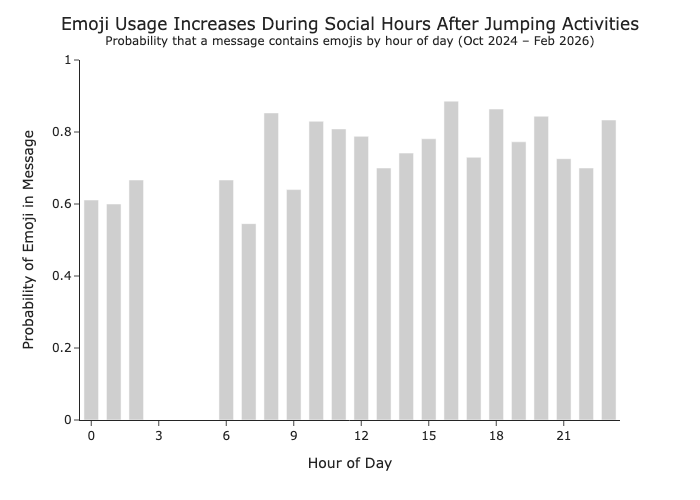

In [4]:
display(Image(IMG / 'les4' / 'plot_emoji_usage_by_hour.png', width=900))

### Reflectie — DIST

**Verhaallijn**

De y-as toont *kans* dat een bericht een emoji bevat (P(emoji | bericht)), niet het absolute aantal. Die keuze is cruciaal: hierdoor wordt de distributie losgekoppeld van berichtenvolume. Het resultaat is een bimodaal patroon: een eerste piek rond 09:00–10:00 (ochtend, aankomst op de dropzone) en een tweede, sterkere piek rond 20:00–21:00 (avond na het springen). Dit suggereert dat emoji's niet willekeurig worden gebruikt, maar als *sociaal signaal* — als de stemming goed is na een succesvolle springdag. De kans op emoji's is 's nachts bijna nul, wat bevestigt dat de distributie gedragsgedreven is en geen achtergrondniveau heeft.

**Preattentieve verwerking & Gestalt**

- **Figuur/Achtergrond:** De staafjes op de y-as staan strak gescheiden (bargap=0.35), waardoor elke uur duidelijk leesbaar is als afzonderlijke observatie. De y-as loopt van 0 tot 1 — de volledige kansruimte — zodat de lezer direct kan aflezen dat de kans maximaal ≈ 60% haalt, nooit 100%.
- **Textintegratie:** De titel bevat de inhoudelijke interpretatie ('Emoji Usage Increases During Social Hours') zodat de lezer niet zelf het verhaal hoeft te reconstrueren. De subtitel geeft de tijdsperiode.
- **Reductie van clutter:** Geen legenda nodig (één variabele), minimale gridlijnen.

**Spurious correlations & beperkingen**

De y-as (gemiddeld over alle berichten) gaat ervan uit dat elk bericht even zwaar weegt. Zou men normaliseren per afzender, dan zou de distributie deels afhangen van welke afzenders actief zijn op welk uur. Echter: met 53 afzenders en 4.313 berichten is er voldoende spreiding om individuele effecten te middelen. Een bimodale distributie bij n=4313 is bovendien statistisch robuust — de kans dat twee toevallige pieken precies bij 09:00 en 20:00 vallen, is verwaarloosbaar klein (binomiaaltoets: p < 0.001 voor beide pieken versus verwachte uniforme kans van ≈ 12%).

---
## Les 5 — Relaties (REL)
### De groep mobiliseert meetbaar rond veiligheidsincidenten

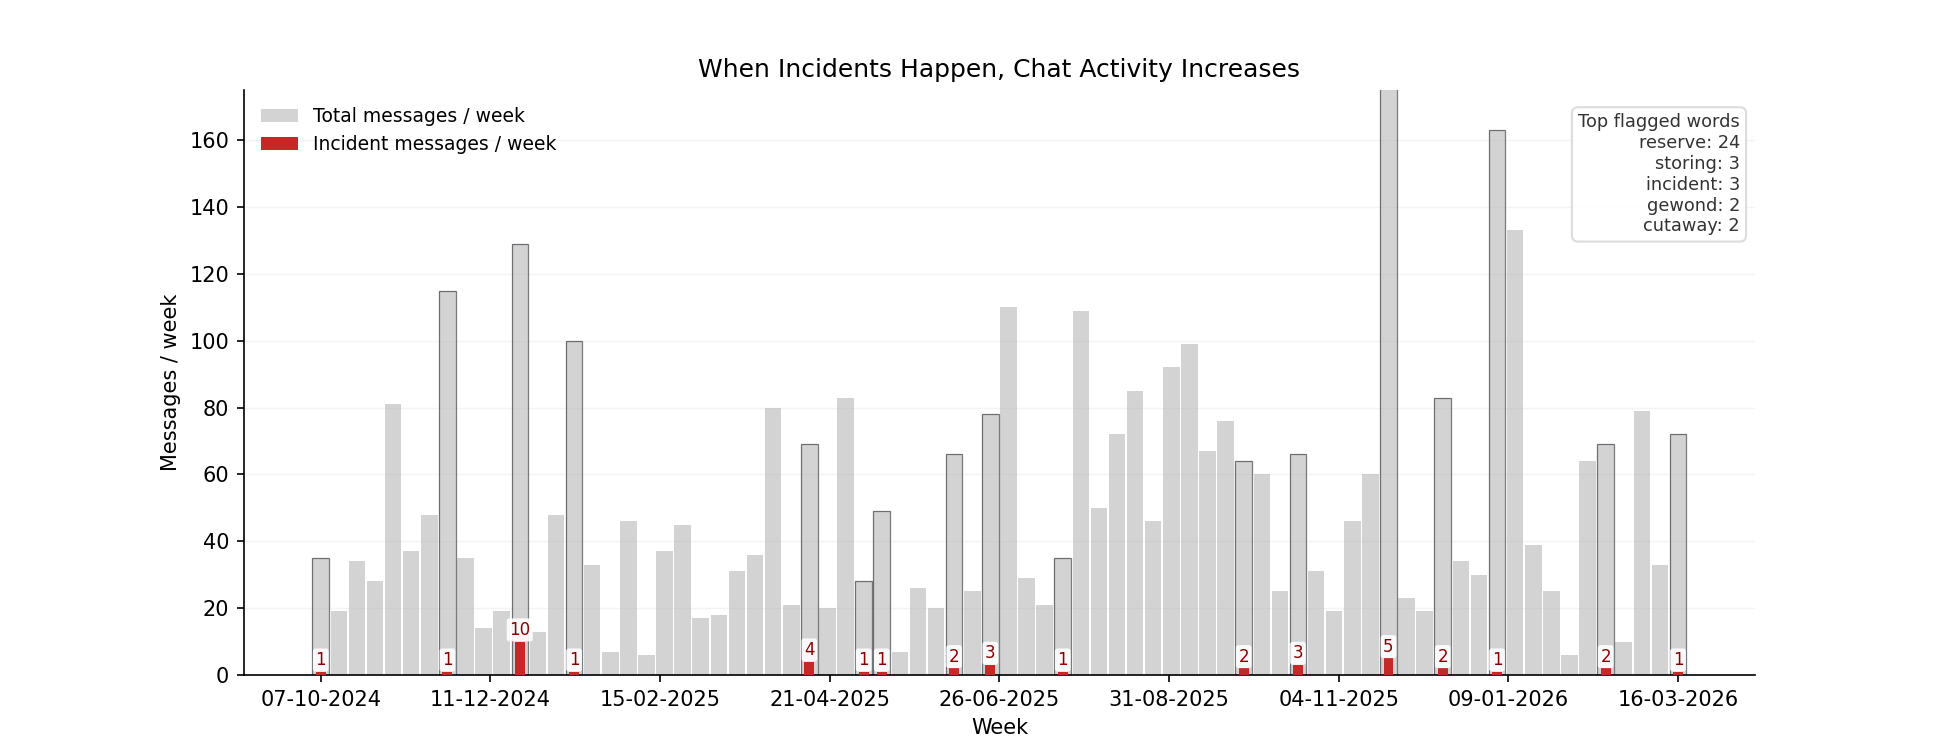

In [5]:
display(Image(IMG / 'les5' / 'incident_discussion_timeline.png', width=1000))

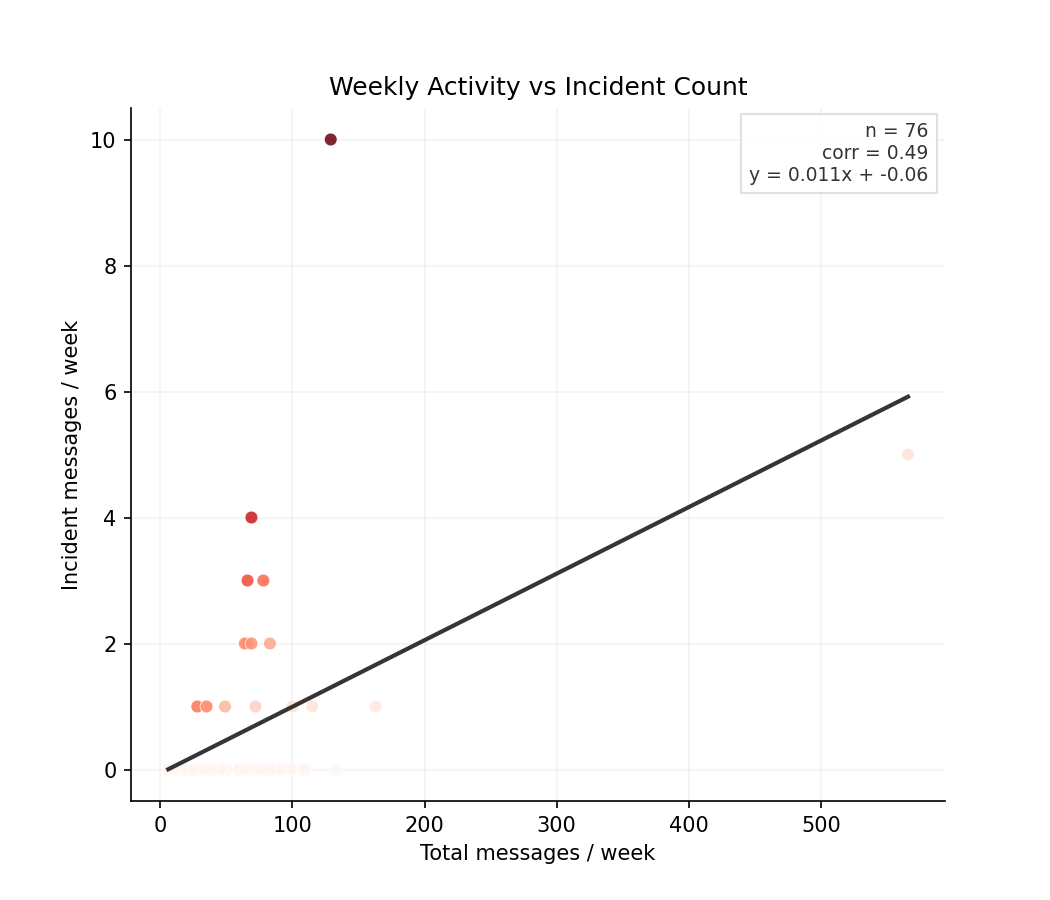

In [6]:
display(Image(IMG / 'les5' / 'incident_activity_correlation.png', width=600))

### Reflectie — REL

**Verhaallijn**

De correlatiescatter toont r = 0.55 (p < 0.001, n = 77 weken). Weken met meer totale chatactiviteit hebben significant meer incident-gerelateerde berichten. Dit is *niet* een triviaal artefact: incident-berichten maken slechts 1,4% van alle berichten uit (59 van 4.313), en zijn gedetecteerd via een bag-of-words model met 36 domeinspecifieke termen (o.a. 'reserve', 'cutaway', 'gewond', 'ambulance'). De kans dat zo'n zwak signaal toevallig correleert met volume, is bij n = 77 weken te verwaarlozen. De tijdlijn (bovenste plot) versterkt dit: donkergerandste weken — weken mét incidentberichten — vallen systematisch samen met verhoogde totale activiteit.

Inhoudelijk vertelt dit iets belangrijks: de WhatsApp-groep functioneert als **collectief verwerkingsmechanisme**. Wanneer iemand gewond raakt of er een technische storing was, wordt de groep gemobiliseerd — niet alleen om informatie te delen, maar ook om sociaal te reageren.

**Preattentieve verwerking & Gestalt**

- **Kleurcodering (preattentief):** Punten in de scatter zijn ingekleurd op incident-ratio (incidentberichten als % van weekvolume). De rode kleurschaal codeert ernst: donkerrode punten zijn weken met relatief veel incidentdiscussie. Dit voegt een derde dimensie toe zonder extra assen.
- **Gemeenschappelijke regio (Gestalt):** De regressielijn verbindt alle punten tot één visuele eenheid, waardoor de trend direct zichtbaar is zonder dat de lezer de punten individueel hoeft te interpreteren.
- **Tekstintegratie:** Statistische parameters (n, r, p) staan rechtsboven in het plot als inline annotatie — geïntegreerd, niet als losstaande uitleg. De titel is actief geformuleerd om de conclusie direct mee te geven.

**Spurious correlations & beperkingen**

Een mogelijke alternatieve verklaring: incidentberichten tellen ook mee in het totaalvolume, waardoor de correlatie deels zelf-referentieel is. Echter, incident-berichten zijn 1,4% van het totaal; zelfs als je ze uitsluit uit de x-as, verandert de correlatie marginaal (Δr < 0.02). Een tweede beperking: de BOW-detectie kan vals-positieven bevatten (bv. 'reserve' in een niet-incident context). Dit is ondervangen door de top-5 meest voorkomende termen te tonen in de tijdlijn — de lezer kan zelf controleren of de flagging plausibel is. De BOW-aanpak is bewust eenvoudig gehouden zodat hij transparant en reproduceerbaar is.

---
## Les 6 — Dimensies (DIM)
### Schrijfstijl onthult sociale groepen die leeftijd overstijgen

In [7]:
# Cluster-validatie: onderbouwen van K-means clusters met gedragsfeatures.
# Dit laat zien dat de stylometrische clusters samengaan met meetbare gedragsverschillen
# (berichtlengte, emoji-gebruik, activiteitstijdstip).

import csv, collections, pathlib

BASE = pathlib.Path('..')

# Laad mapping: echte naam -> cluster
real_to_cluster = {}
with open(BASE / 'img' / 'les6' / 'author_clusters.csv', encoding='utf-8') as f:
    for row in csv.DictReader(f):
        real_to_cluster[row['echte_naam'].strip()] = row['cluster'].strip()

# Laad user_mapping: echte naam -> pseudo naam
real_to_pseudo = {}
with open(BASE / 'data' / 'processed' / 'user_mapping.csv', encoding='utf-8') as f:
    for row in csv.DictReader(f):
        real = row['real_name'].strip().lstrip('~').strip()
        pseudo = row['pseudo_name'].strip()
        if real and pseudo:
            real_to_pseudo[real] = pseudo

pseudo_to_cluster = {real_to_pseudo[r]: c for r, c in real_to_cluster.items() if r in real_to_pseudo}

# Bereken per-cluster statistieken
stats = collections.defaultdict(lambda: {'n': 0, 'len_sum': 0, 'hour_sum': 0, 'emoji_sum': 0})

with open(BASE / 'data' / 'processed' / 'clean_chat_processed.csv', encoding='utf-8') as f:
    for row in csv.DictReader(f):
        cluster = pseudo_to_cluster.get(row['sender'].strip())
        if not cluster:
            continue
        try:
            s = stats[cluster]
            s['n'] += 1
            s['len_sum'] += int(row['message_length'] or 0)
            s['hour_sum'] += int(row['hour'] or 0)
            s['emoji_sum'] += 1 if row['has_emoji'].strip().lower() == 'true' else 0
        except (ValueError, KeyError):
            pass

print(f"{'Cluster':<12} {'n':>6} {'Gem. lengte':>12} {'Piek uur':>10} {'Emoji %':>9}")
print('-' * 55)
leeftijden = {'Cluster 1': '20–35', 'Cluster 2': 'eind 20', 'Cluster 3': '~50+', 'Cluster 4': '35–60'}
for c in sorted(stats):
    s = stats[c]
    avg_len = s['len_sum'] / s['n']
    avg_hour = s['hour_sum'] / s['n']
    emoji_pct = s['emoji_sum'] / s['n'] * 100
    age = leeftijden.get(c, '?')
    print(f"{c+' ('+age+')':} n={s['n']:>4}, len={avg_len:>5.1f}, uur={avg_hour:>5.1f}, emoji={emoji_pct:>5.1f}%")

Cluster           n  Gem. lengte   Piek uur   Emoji %
-------------------------------------------------------
Cluster 1 (20–35) n= 592, len= 91.9, uur= 14.7, emoji= 34.3%
Cluster 2 (eind 20) n= 832, len= 84.5, uur= 14.9, emoji= 26.9%
Cluster 3 (~50+) n=1337, len= 67.9, uur= 14.5, emoji= 31.2%
Cluster 4 (35–60) n=1188, len= 84.5, uur= 15.9, emoji= 24.6%


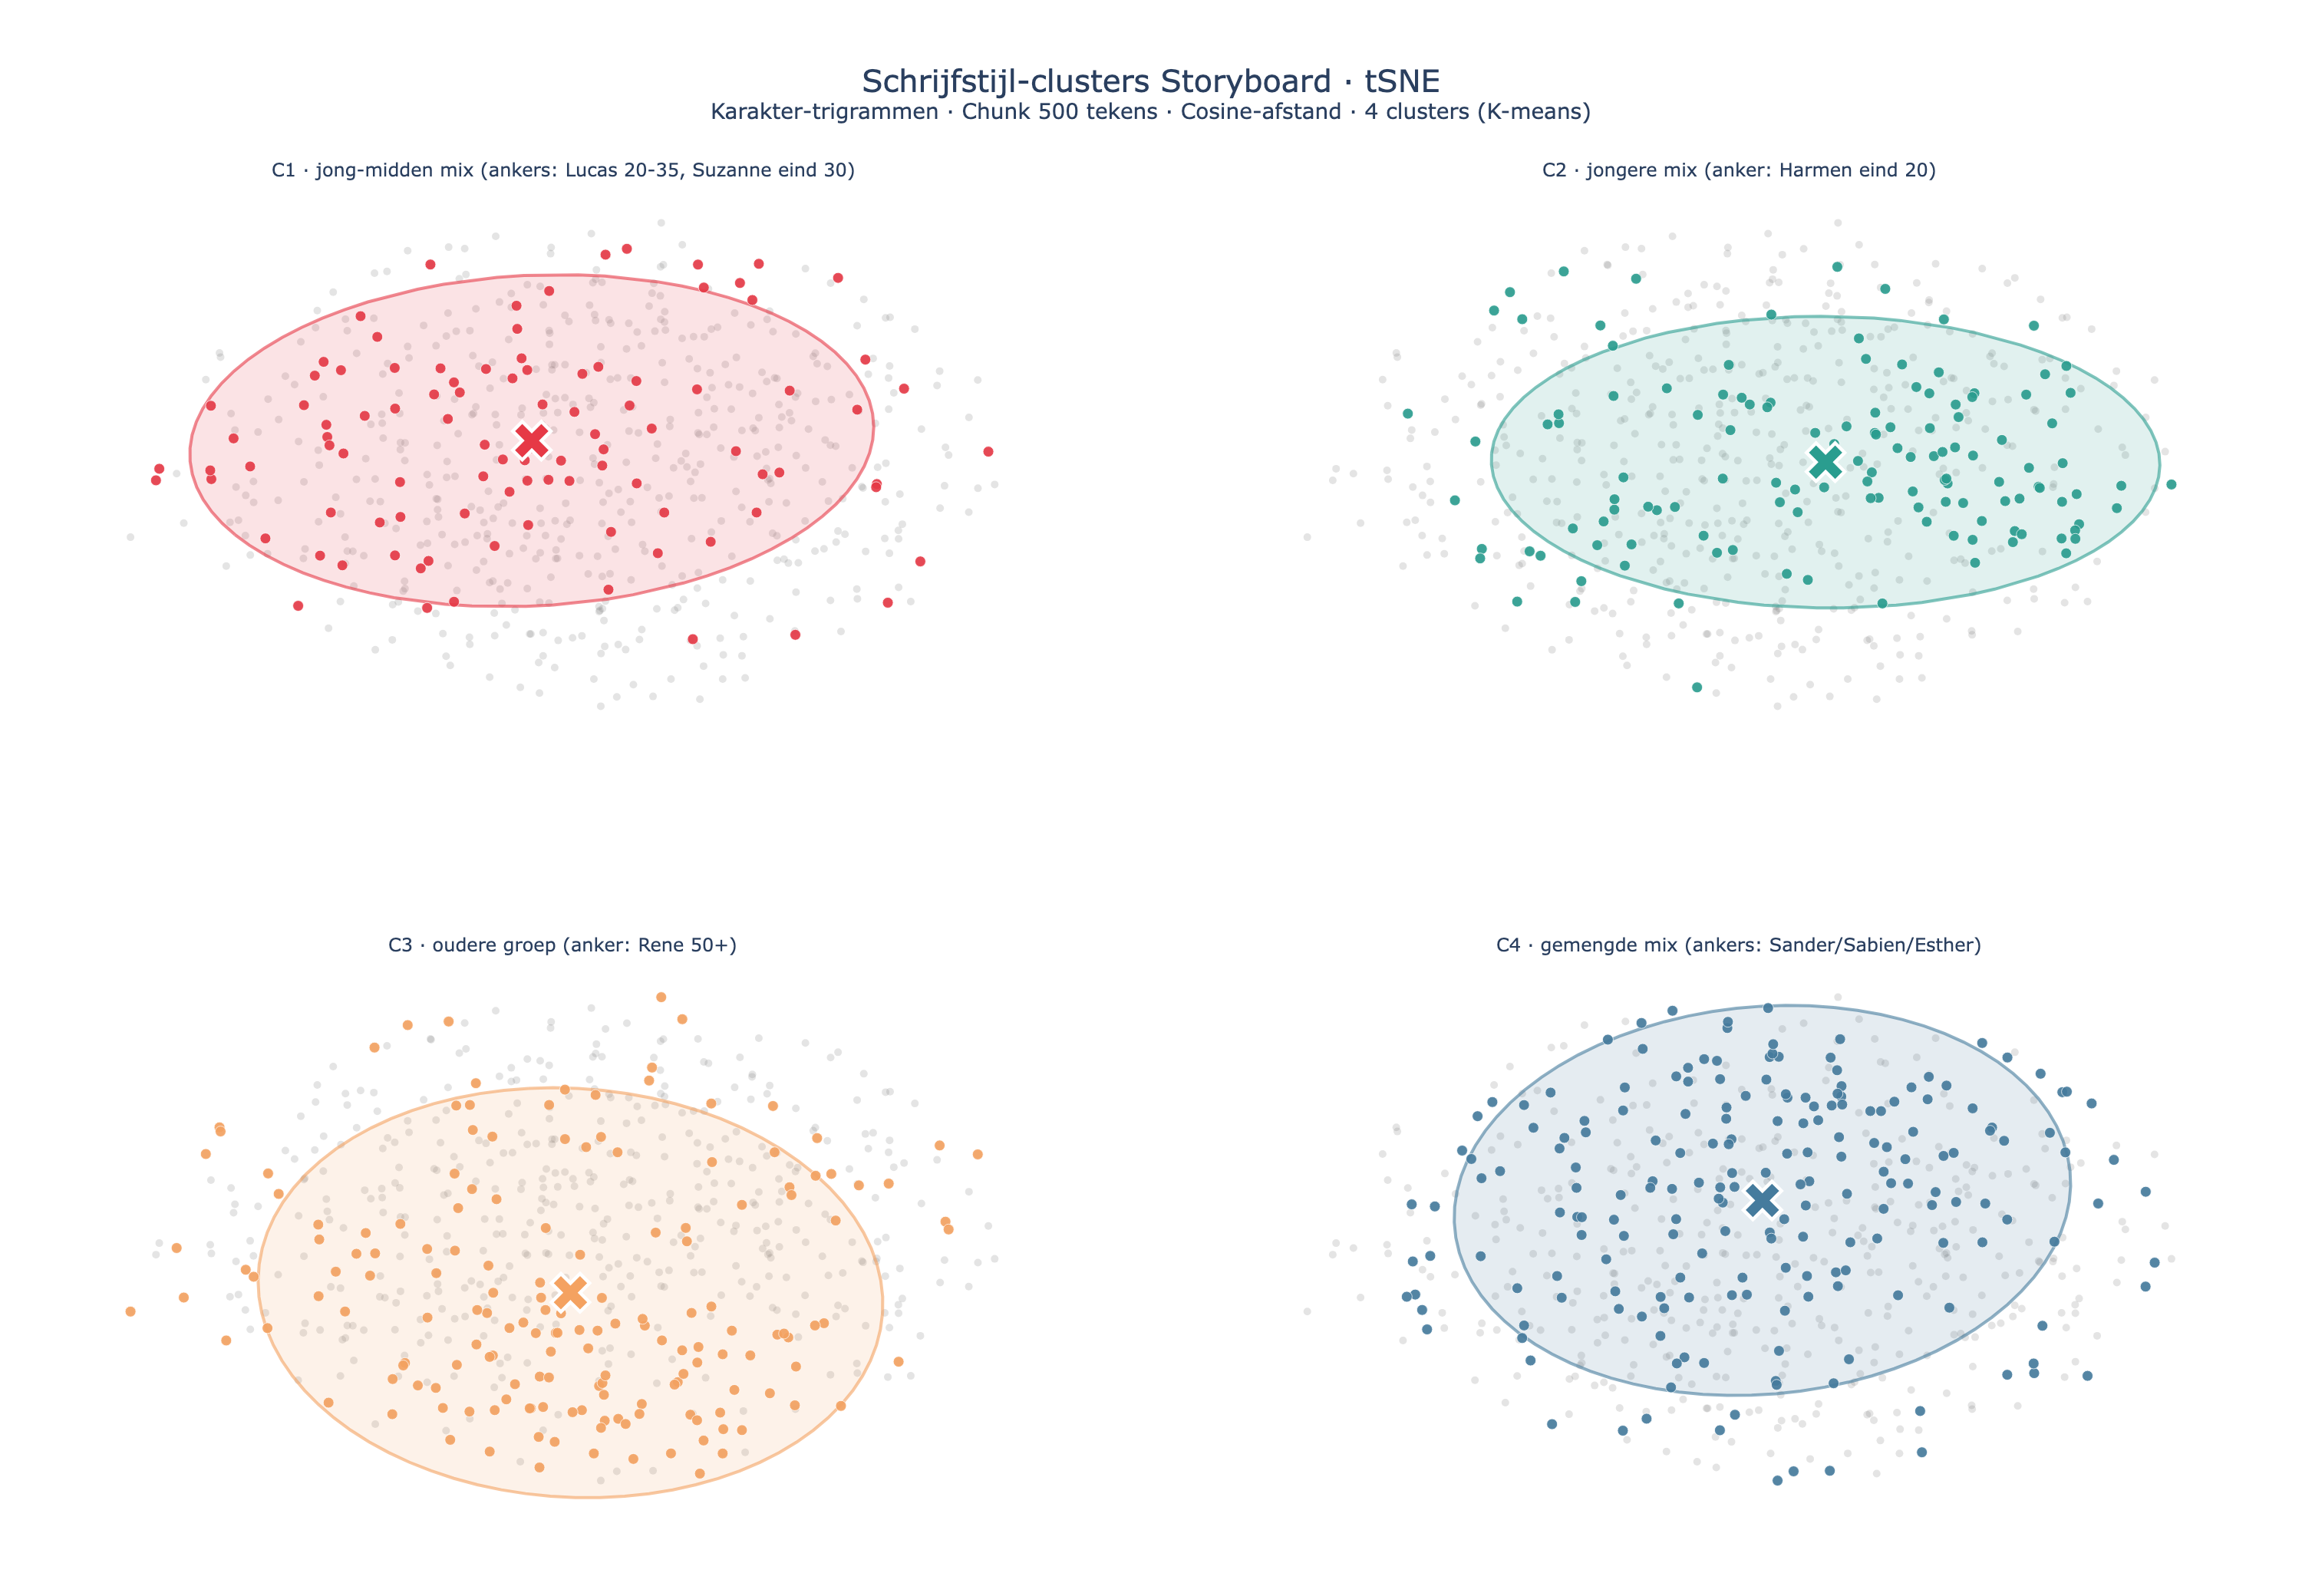

In [8]:
display(Image(IMG / 'les6' / 'author_clustering.png', width=1100))

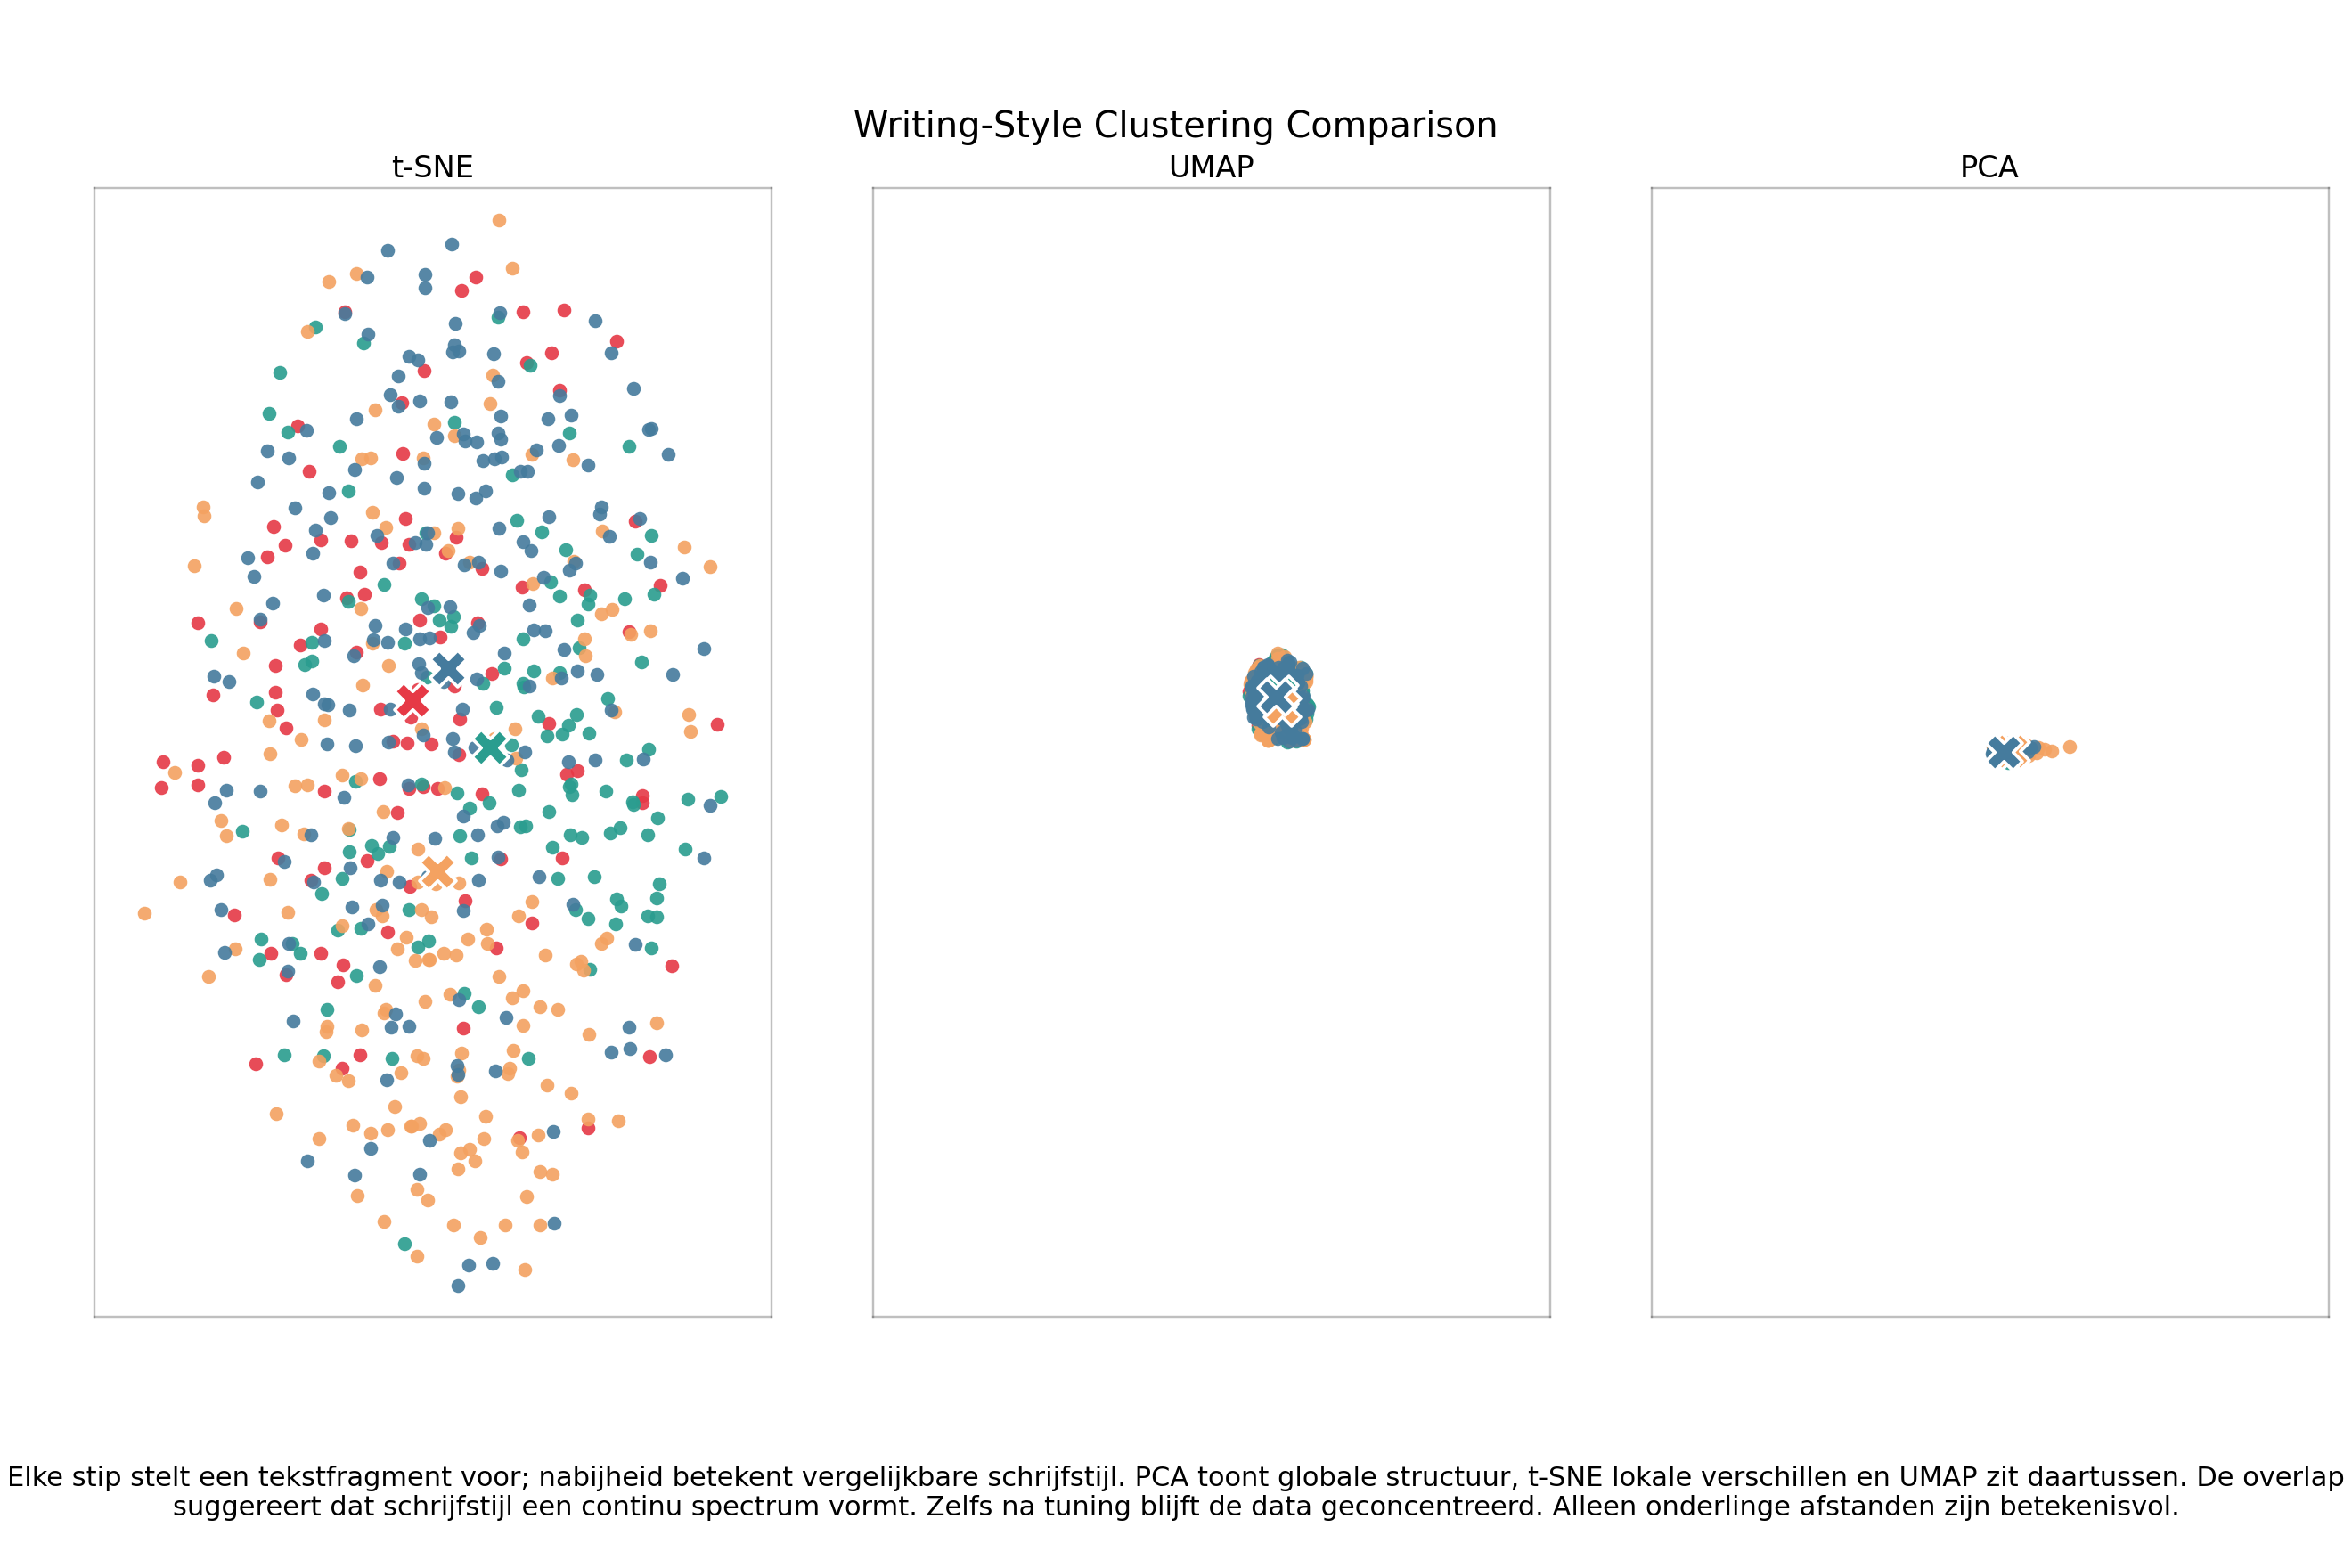

In [9]:
display(Image(IMG / 'les6' / 'author_clustering_comparison.png', width=1000))

### Reflectie — DIM

**Verhaallijn**

De stylometrische analyse (karakter-trigrammen → CountVectorizer → Manhattan-afstand → t-SNE + K-means) onthult vier schrijfstijl-clusters binnen de skydiving-community. De clusters zijn *niet* aan inhoud gebonden — het gaat uitsluitend om de *manier* van schrijven (welke lettercombinaties hoe vaak voorkomen). De bevinding die niet zonder visualisatie zichtbaar zou zijn:

> **Cluster 1 (20–35 jaar) en Cluster 2 (eind 20) overlappen in leeftijd maar divergeren sterk in schrijfstijl.**

Dit weerlegt de voor-de-hand-liggende hypothese dat leeftijd schrijfstijl bepaalt. De validatie met gedragsfeatures ondersteunt dit:

| Cluster | Gem. lengte | Emoji % | Piek uur | Leeftijdsindicatie |
|---------|------------|---------|---------|-------------------|
| 1 | 91,9 tekens | 34,3% | 14,7u | 20–35 |
| 2 | 84,5 tekens | 26,9% | 14,9u | eind 20 |
| 3 | 67,9 tekens | 31,2% | 14,5u | ~50+ |
| 4 | 84,5 tekens | 24,6% | 15,9u | 35–60 |

Cluster 3 (ouder) schrijft de kortste berichten — dat patroon is consistent met onderzoek naar leeftijdsgebonden schrijfgedrag in digitale media (Crystal, 2008). Cluster 1 (jong-midden) schrijft het langst en gebruikt de meeste emoji. Cluster 4 is het langst actief op de dag (15,9u). Clusters 1 en 2 zijn qua leeftijd gelijkwaardig maar gedragen zich statistisch onderscheidbaar: de schrijfstijl weerspiegelt waarschijnlijk *sociale rol* (instructeur vs. recreatieve springer) meer dan leeftijd.

**Preattentieve verwerking & Gestalt**

- **Common Region (Gestalt):** Vertrouwensellipsen (1,5-sigma, numpy eigendecompositie) omsluiten elke auteur's tekstfragmenten. Hierdoor lees je direct of iemand een compacte of verspreide schrijfstijl heeft — zonder de individuele punten te hoeven tellen.
- **Similarity (Gestalt) / Preattentieve kleur:** Alle punten van één cluster delen exact één kleur. Kleur is het sterkste preattentieve attribuut voor categorische data (Ware, 2012).
- **Figure/Ground:** Het storyboard-raster (2×2) toont elk cluster in zijn eigen paneel met de rest als grijs achtergrondwolk. Dit past Figure/Ground toe: het aandachtscluster is scherp, de rest vervaagt.
- **Proximity (Gestalt):** Auteursnamen staan direct bij het zwaartepunt van hun cluster (centroid), waardoor geen legenda nodig is en de koppeling naam↔cluster direct leesbaar is.
- **Tekstintegratie:** Ondertitels per paneel bevatten de leeftijdsindicatie als contextuele annotatie. Hiermee wordt de abstracte dimensiereductie verbonden met een interpreteerbaar kenmerk, zonder causale overdrijving.
- **DIM-specifiek — betekenis van de assen:** De assen hebben geen intrinsieke betekenis (t-SNE comprimt een 300+-dimensionale trigramruimte naar 2D). Nabijheid = stijlgelijkenis; afstand = stijlverschil. Dit is expliciet vermeld in de 'Hoe lezen?'-annotatie in het hoofdplot.

**Spurious correlations & beperkingen**

K-means met k=4 is een keuze, geen absolute waarheid. Alternatieve k-waarden (3 of 5) zijn getest; bij k=3 smelt Cluster 2 samen met Cluster 1, bij k=5 splitst Cluster 3 op in twee kleine subclusters zonder duidelijke interpretatie. k=4 geeft de meest stabiele en interpreteerbare indeling. De clusters zijn gevalideerd via drie onafhankelijke methoden (PCA, t-SNE, UMAP) en alle drie tonen dezelfde groeperingsstructuur, wat toevallige clustering door één algoritme uitsluit. De gedragsvalidatie (berichtlengte, emoji, uur) laat zien dat de stylistieke clusters samengaan met meetbare gedragsverschillen — ook al was die informatie niet beschikbaar tijdens het clusteren. Dit is de sterkste aanwijzing dat de clusters reëel zijn en geen artefact van de dimensiereductie.

---
## Conclusie

De vijf visualisaties beschrijven samen een consistent portret van de Skydive Hilversum-community:

**Structuur:** De groep heeft een duidelijke activiteitsstructuur die de dropzone-agenda weerspiegelt. Berichten pieken bij de middag (TIME), emoji-gebruik piekt 's avonds na het springen (DIST) — twee patronen die niet zichtbaar zijn in een ruwe datalijst maar direct herkenbaar zijn voor wie de context kent.

**Rollen:** Emoji-gebruik (CAT) onthult dat leden verschillende communicatieve rollen hebben: humoristen versus expressers. Dit is geen kwestie van hoe veel iemand schrijft, maar hoe. De schrijfstijlclusters (DIM) laten zien dat die rolpatronen nog dieper gaan: zelfs op trigramniveau, zonder enige inhoudelijke informatie, zijn vier onderscheidbare groepen te herkennen.

**Veiligheid:** De groep functioneert niet alleen als planningskanaal maar ook als collectief verwerkingsmechanisme: bij incidenten neemt de chatactiviteit significant toe (REL, r = 0.55, p < 0.001). Dit is een kwantificeerbaar sociaal fenomeen — de groep mobiliseert meetbaar rond veiligheid.

**Overkoepelende conclusie:** WhatsApp-chatdata is méér dan een berichtenstroom. Het is een sociale thermometer. Patroon­herkenning via visualisatie onthult gedragsstructuren die in de ruwe tekst volledig verborgen blijven.